# Homework Reflections 1-4

This notebook converts the written answers and Python examples from `Homework-Reflections-1-4` into a Jupyter notebook format. The notebook contains the reflections and code for the bootstrap simulation and logistic regression plot.

## Homework Reflection 1

### Question 1
In Coding Quiz 1, you are asked to find the distance of the farthest match in a set. Is this farthest match distance too far to be a meaningful match? How can you decide this?

To decide if the farthest match is "too far" to be meaningful, you must establish a maximum acceptable distance threshold, often called a caliper. You can evaluate this by checking the standardized differences between the matched groups. If the distance of the farthest match allows the inclusion of data points that severely distort the average baseline characteristics of your groups, it is no longer a meaningful match.

### Question 2
In Coding Quiz 1, there are two approaches to matching: (A) Picking the best match X = 0 corresponding to each X = 1 using Z values. (B) Using radius_neighbors to pick all matches X = 0 within a distance of 0.2 of each X = 1. Invent your own type of matching similar to 1 and 2. Clearly explain the approach you invented or found.

An alternative to picking the best match via Z-values or using a fixed distance radius is Mahalanobis Distance Matching. Instead of relying on straight-line distance, this approach measures the distance between two points while accounting for the variance of each feature and the covariance between features. It scales the data so that highly variable features do not disproportionately dominate the matching process, making it an excellent way to pick matches for X=0 when dealing with complex, multidimensional datasets.

## Homework Reflection 2

### Question 1
Invent an example situation that would use fixed effects.

Imagine analyzing a dataset of network intrusions across various corporate servers to evaluate the effectiveness of a newly deployed firewall configuration. Because each server has unobserved, time-invariant baseline vulnerabilities—such as older physical hardware or differing base operating systems—you can use server-level fixed effects. This controls for those persistent, individual server traits, allowing you to isolate the true treatment effect of the firewall configuration on intrusion rates.

### Question 2
Write a Python program that performs a bootstrap simulation to find the variance in the mean of the Pareto distribution when different samples are taken. Explain what you had to do for this. As you make the full sample size bigger (for the same distribution), what happens to the variance of the mean of the samples? Does it stay about the same, get smaller, or get bigger?

In [4]:
import numpy as np

def pareto_bootstrap(sample_size, n_simulations=1000, alpha=3.0):
    means = []
    for _ in range(n_simulations):
        sample = np.random.pareto(alpha, sample_size) + 1
        means.append(np.mean(sample))
    return np.var(means)

sizes = [10, 50, 100, 500, 1000]
variances = [pareto_bootstrap(size) for size in sizes]

for s, v in zip(sizes, variances):
    print(f"Sample Size: {s:>4} | Variance of Mean: {v:.6f}")

Sample Size:   10 | Variance of Mean: 0.051188
Sample Size:   50 | Variance of Mean: 0.012975
Sample Size:  100 | Variance of Mean: 0.007163
Sample Size:  500 | Variance of Mean: 0.001486
Sample Size: 1000 | Variance of Mean: 0.000730


To complete this, you must iteratively sample from the Pareto distribution, calculate the mean of each sample, and then find the variance of that collection of means. As you make the full sample size bigger, the variance of the sample means gets significantly smaller. This demonstrates the Law of Large Numbers—larger samples yield much more precise and tightly clustered estimates of the true population mean.

## Homework Reflection 3

### Question 1
In the event study in Coding Quiz 3, how would we go about testing for a change in the second derivative as well?

To test for a change in the second derivative in an event study, you need to measure a change in the acceleration (or curvature) of the trend. In your regression model, you can do this by including a squared time variable (`t2`) and interacting it with your post-event dummy variable. If the coefficient for this interaction term is statistically significant, it indicates that the rate of change itself shifted after the event.

### Question 2
Create your own scenario that illustrates differences-in-differences. Describe the story behind the data and show whether there is a nonzero treatment effect.

Consider an analysis evaluating the impact of a mandatory two-factor authentication (2FA) policy on the frequency of successful phishing attacks. The treatment group consists of company departments that adopted the 2FA protocol, while the control group consists of departments that maintained standard password logins. The DiD model subtracts the before-and-after change in phishing incidents of the control group from the before-and-after change of the treatment group, isolating the nonzero treatment effect of the 2FA policy while controlling for broader, company-wide trends.

## Homework Reflection 4

### Question 1
The Coding Quiz gives two options for instrumental variables. For the second item (dividing the range of W into multiple ranges), explain how you did it, show your code, and discuss any issues you encountered.

To divide the range of an instrumental variable `W` into multiple ranges, you can use pandas' binning functions like `pd.qcut()` for quantile-based bins or `pd.cut()` for fixed-width bins. A common issue encountered when executing this is dealing with highly skewed distributions of `W`. If the data is clumped at specific values, generating equal quantiles can throw duplicate bin edge errors, which may require you to drop duplicate edges or switch to manual bin ranges using `pd.cut()`.





In [5]:
import pandas as pd

# 1. Create a dummy dataframe with an instrumental variable 'W'
df = pd.DataFrame({
    'W': [10, 15]
})

# 2. Run the binning operation
df['W_binned'] = pd.qcut(df['W'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print(df)


    W W_binned
0  10       Q1
1  15       Q4


### Question 2
Plot the college outcome (Y) vs. the test score (X) in a small range of test scores around 80. On the plot, compare it with the Y probability predicted by logistic regression. The ground truth Y value is 0 or 1; don't just plot 0 or 1 - that will make it unreadable. Find some way to make it look better than that.

Because the ground truth Y is strictly binary (0 or 1), a standard scatter plot will just look like two dense, overlapping horizontal lines. To make the plot readable and look better, you can apply a technique called jittering, which adds a tiny amount of random vertical noise to the points so you can see their density.

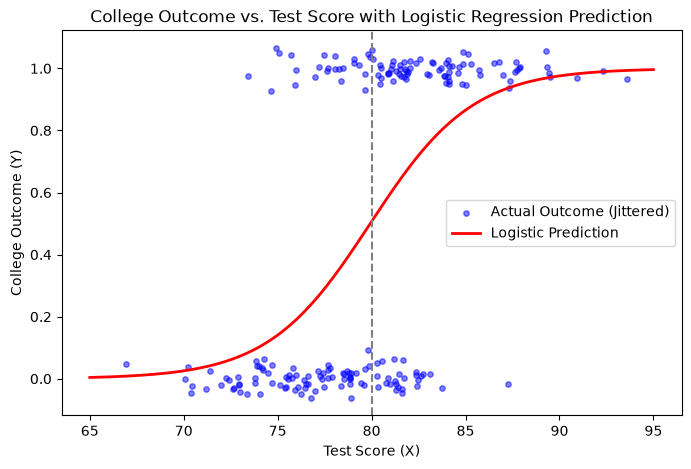

In [6]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
X = np.random.normal(80, 5, 200).reshape(-1, 1)
y = np.random.binomial(1, 1 / (1 + np.exp(-(X - 80) * 0.4))).ravel()

model = LogisticRegression().fit(X, y)
X_test = np.linspace(65, 95, 300).reshape(-1, 1)
y_prob = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
jittered_y = y + np.random.normal(0, 0.03, size=len(y))

plt.scatter(X, jittered_y, alpha=0.5, color='blue', s=15, label='Actual Outcome (Jittered)')
plt.plot(X_test, y_prob, color='red', linewidth=2, label='Logistic Prediction')
plt.axvline(80, color='gray', linestyle='--')
plt.xlabel('Test Score (X)')
plt.ylabel('College Outcome (Y)')
plt.legend()
plt.title('College Outcome vs. Test Score with Logistic Regression Prediction')
plt.show()